# Imports & Setup

In [17]:
# %pip install -U ipykernel pandas numpy pydantic openai ipywidgets ipython tqdm \
#     scikit-learn matplotlib seaborn

In [1]:
import os
import sys
from pathlib import Path
from pprint import pprint

import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from IPython.display import display
from openai import AsyncOpenAI
from tqdm.notebook import tqdm

PROJECT_ROOT = Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ai_leader.phase3_lab import (  # noqa: E402
    EVAL_COLUMNS,
    MODEL_PALETTE,
    MODELS,
    compute_cost,
    compute_hypothesis_metrics,
    evaluate_run,
    run_extraction_async,
    short_name,
)

In [2]:
load_dotenv(".env")  # reads .env into process env

w_api_key = os.getenv("TOKENFACTORY_API_KEY", None) or os.getenv("OPENAI_API_KEY", None)


if not w_api_key:
    w_api_key = widgets.Password(
        value="",
        placeholder="Paste API key (v1...)",
        description="API key:",
        layout=widgets.Layout(width="60%"),
        style={"description_width": "80px"},
    )
    display(w_api_key)
    w_api_key = w_api_key.value


print(w_api_key[:7])

v1.CmQK


# Load Data

In [5]:
# url_gt = (
#     "https://docs.google.com/spreadsheets/d/"
#     "1q_PA_U3JmrIa9u3KYMNIUurB7XZJU_WOn42vpH7jBJM/"
#     "export?format=csv&gid=543702529"
# )
url_gt = "https://docs.google.com/spreadsheets/d/e/2PACX-1vSU5zvx8wgk9FMEcRGlCtXkE4_T90OgsrqU4QPNZC478Rsp5JEBEEUjvlMkY3iMoiAmpa1zQ5QFkgT5/pub?output=csv"
# url_pred = (
#     "https://docs.google.com/spreadsheets/d/"
#     "1q_PA_U3JmrIa9u3KYMNIUurB7XZJU_WOn42vpH7jBJM/"
#     "export?format=csv&gid=1651146594"
# )

df_ground_truth = pd.read_csv(url_gt)
# df_to_predict_raw = pl.read_csv(url_pred)

# df_ground_truth = df_ground_truth_raw.with_row_index("row_id")

In [6]:
print("Ground-truth shape:", df_ground_truth.shape)
display(df_ground_truth.tail(3))

Ground-truth shape: (100, 8)


,Request Text,Submission Channel,Related to order,Order ID,Category,Routing to Department,Timestamp,Order History
97,The delivery truck is too big for my small str...,Chat,True,CK-5588,Delivery,Logistics,2025-10-09 10:00:00,2025-10-01 — Order placed | 2025-10-09 — Lates...
98,Can I exchange my unused store credit for cash?,Email,False,NaN,General Feedback,Customer Support,2025-10-08 16:45:00,NaN
99,Where is my order? I placed it almost two week...,Email,True,CK-5678,Delivery,Customer Support,2025-10-08 16:00:00,2025-09-21 — Order placed for Accessories; pay...


In [7]:
df_ground_truth.tail(3).to_dict(orient="records")

[{'Request Text': 'The delivery truck is too big for my small street. What do we do?',
  'Submission Channel': 'Chat',
  'Related to order': True,
  'Order ID': 'CK-5588',
  'Category': 'Delivery',
  'Routing to Department': 'Logistics',
  'Timestamp': '2025-10-09 10:00:00',
  'Order History': '2025-10-01 — Order placed | 2025-10-09 — Latest customer request logged.'},
 {'Request Text': 'Can I exchange my unused store credit for cash?',
  'Submission Channel': 'Email',
  'Related to order': False,
  'Order ID': nan,
  'Category': 'General Feedback',
  'Routing to Department': 'Customer Support',
  'Timestamp': '2025-10-08 16:45:00',
  'Order History': nan},
 {'Request Text': "Where is my order? I placed it almost two weeks ago and the tracking link still shows 'processing'. Can someone check the status for me urgently?",
  'Submission Channel': 'Email',
  'Related to order': True,
  'Order ID': 'CK-5678',
  'Category': 'Delivery',
  'Routing to Department': 'Customer Support',
  'Times

# Configuration

## System Prompt

In [8]:
DEFAULT_SYSTEM_PROMPT = """\
You are a customer feedback specialist at Candlekeep Retail Group, an enterprise retail \
company focused on apparel, accessories, furniture, and home-living solutions. The company \
operates through e-commerce websites, a mobile app, and retail stores.
You receive customer requests from multiple channels and must classify them and provide an \
initial response.

Task
----
1. Read the customer request and the submission channel.
2. Use the order history as additional context when provided.
3. Return **only** valid JSON matching the given schema — no extra fields.
4. Choose the single best value for:
   • Category. Available options are: ['Payment', 'Order Issue', 'Delivery', \
'General Feedback']
   • Routing to Department. Available options are: ['Customer Support', 'Returns', \
'Product Team', 'Logistics']
5. Write a professional, concise, helpful initial response in the
   "[Agent] Initial Response" field.
"""
pprint(DEFAULT_SYSTEM_PROMPT)

('You are a customer feedback specialist at Candlekeep Retail Group, an '
 'enterprise retail company focused on apparel, accessories, furniture, and '
 'home-living solutions. The company operates through e-commerce websites, a '
 'mobile app, and retail stores.\n'
 'You receive customer requests from multiple channels and must classify them '
 'and provide an initial response.\n'
 '\n'
 'Task\n'
 '----\n'
 '1. Read the customer request and the submission channel.\n'
 '2. Use the order history as additional context when provided.\n'
 '3. Return **only** valid JSON matching the given schema — no extra fields.\n'
 '4. Choose the single best value for:\n'
 "   • Category. Available options are: ['Payment', 'Order Issue', 'Delivery', "
 "'General Feedback']\n"
 "   • Routing to Department. Available options are: ['Customer Support', "
 "'Returns', 'Product Team', 'Logistics']\n"
 '5. Write a professional, concise, helpful initial response in the\n'
 '   "[Agent] Initial Response" field.\n

## Settings

In [9]:
MAX_CONCURRENCY = 10
TEMPERATURE = 0.1
BASELINE_N_SHOT = 0  # fixed few-shot count for Phase 1
FEW_SHOT_COUNTS = [0, 1, 2, 4, 8]  # used in Phase 2

# Phase 1 — Model Selection (0-shot baseline + cost)

Run every model at BASELINE_N_SHOT, collect quality metrics and token usage, then pick the most cost-efficient model.

In [10]:
assert w_api_key, "Please enter your API key in the widget above."
client = AsyncOpenAI(
    base_url="https://api.tokenfactory.nebius.com/v1/",
    api_key=w_api_key,
)

In [11]:
phase1_results = []

few_shot_df_p1 = df_ground_truth.head(BASELINE_N_SHOT) if BASELINE_N_SHOT > 0 else None
eval_df_p1 = df_ground_truth.iloc[BASELINE_N_SHOT:]
n_eval_p1 = len(eval_df_p1)

for idx, model in enumerate(MODELS, 1):
    label = f"[Phase 1 · {idx}/{len(MODELS)}] {short_name(model)}  n-shot={BASELINE_N_SHOT}"

    progress = tqdm(total=n_eval_p1, desc=label)
    pred_df, usage = await run_extraction_async(
        df=eval_df_p1,
        few_shot_df=few_shot_df_p1,
        max_concurrency=MAX_CONCURRENCY,
        model=model,
        system_prompt=DEFAULT_SYSTEM_PROMPT,
        temperature=TEMPERATURE,
        progress_bar=progress,
        client=client,
    )
    progress.close()

    metrics = evaluate_run(eval_df_p1, pred_df)
    cost_usd = compute_cost(usage, model)

    for gt_col, col_m in metrics.items():
        phase1_results.append(
            {
                "model": model,
                "model_short": short_name(model),
                "target_column": gt_col,
                "accuracy": round(col_m["accuracy"], 4),
                "f1_macro": round(col_m["f1_macro"], 4),
                "prompt_tokens": usage["prompt_tokens"],
                "completion_tokens": usage["completion_tokens"],
                "cost_usd": round(cost_usd, 6),
            }
        )

[Phase 1 · 1/3] DeepSeek-V3.2  n-shot=0:   0%|          | 0/100 [00:00<?, ?it/s]

KeyError: 'row_id'

In [ ]:
df_phase1 = pd.DataFrame(phase1_results)
display(df_phase1)

model,model_short,target_column,accuracy,f1_macro,prompt_tokens,completion_tokens,cost_usd
str,str,str,f64,f64,i64,i64,f64
"""deepseek-ai/DeepSeek-V3.2""","""DeepSeek-V3.2""","""Category""",0.69,0.6829,25048,11137,0.012526
"""deepseek-ai/DeepSeek-V3.2""","""DeepSeek-V3.2""","""Routing to Department""",0.52,0.4415,25048,11137,0.012526
"""zai-org/GLM-5""","""GLM-5""","""Category""",0.87,0.8647,25137,130803,0.443707
"""zai-org/GLM-5""","""GLM-5""","""Routing to Department""",0.51,0.4774,25137,130803,0.443707
"""openai/gpt-oss-120b""","""gpt-oss-120b""","""Category""",0.85,0.8486,31401,29888,0.022643
"""openai/gpt-oss-120b""","""gpt-oss-120b""","""Routing to Department""",0.82,0.8112,31401,29888,0.022643


## Phase 1 — Cost-Efficiency Visualisation

In [ ]:
# Aggregate across both targets: mean accuracy & f1_macro, total cost
df_phase1 = pd.DataFrame(phase1_results)
phase1_agg = (
    df_phase1.groupby("model", as_index=False)
    .agg(
        model_short=("model_short", "first"),
        avg_accuracy=("accuracy", "mean"),
        avg_f1_macro=("f1_macro", "mean"),
        cost_usd=("cost_usd", "first"),
        prompt_tokens=("prompt_tokens", "first"),
        completion_tokens=("completion_tokens", "first"),
    )
    .reset_index(drop=True)
)
display(phase1_agg)

,model,model_short,avg_accuracy,avg_f1_macro,cost_usd,prompt_tokens,completion_tokens
0,deepseek-ai/DeepSeek-V3.2,DeepSeek-V3.2,0.605,0.56220,0.012526,25048,11137
1,openai/gpt-oss-120b,gpt-oss-120b,0.835,0.82990,0.022643,31401,29888
2,zai-org/GLM-5,GLM-5,0.690,0.67105,0.443707,25137,130803


### Bar chart — F1 Macro vs Cost

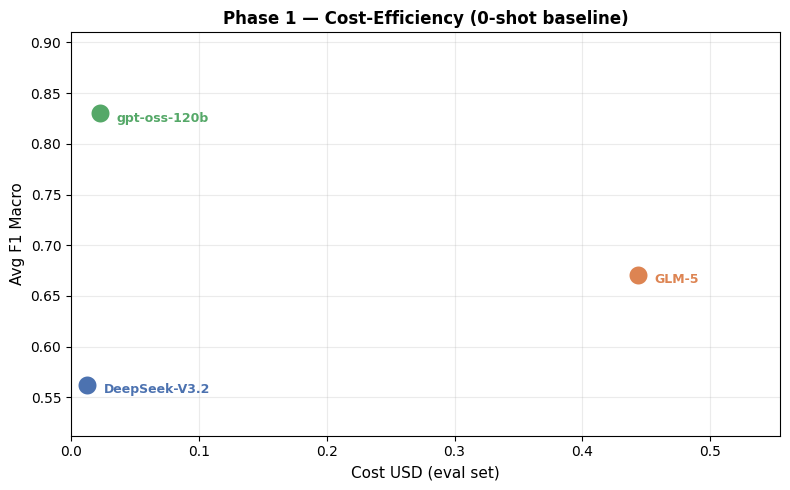

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

models_sorted = phase1_agg["model"].tolist()
f1_vals = phase1_agg["avg_f1_macro"].tolist()
cost_vals = phase1_agg["cost_usd"].tolist()

for m, f1, cost in zip(models_sorted, f1_vals, cost_vals, strict=True):
    ax.scatter(
        cost,
        f1,
        s=200,
        color=MODEL_PALETTE[m],
        edgecolors="white",
        linewidths=1.2,
        zorder=3,
    )
    ax.annotate(
        f"{short_name(m)}",
        (cost, f1),
        textcoords="offset points",
        xytext=(12, -6),
        fontsize=9,
        fontweight="bold",
        color=MODEL_PALETTE[m],
    )


ax.set_xlabel("Cost USD (eval set)", fontsize=11)
ax.set_ylabel("Avg F1 Macro", fontsize=11)
ax.set_title("Phase 1 — Cost-Efficiency (0-shot baseline)", fontweight="bold")
ax.set_ylim(min(f1_vals) - 0.05, max(f1_vals) + 0.08)
ax.set_xlim(0, max(cost_vals) * 1.25)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

### Select best model by cost-efficiency

In [ ]:
best_model = phase1_agg.sort_values("avg_f1_macro", ascending=False).iloc[0]
print(
    f"\n🏆  Selected model:\n{best_model.model}  "
    f"\nAccuracy: {best_model.avg_accuracy}  "
    f"\nF1 Macro {best_model.avg_f1_macro}  "
    f"\nCost: {best_model.cost_usd}  "
)


🏆  Selected model:
openai/gpt-oss-120b  
Accuracy: 0.835  
F1 Macro 0.8299000000000001  
Cost: 0.022643  


# Phase 2 — Few-Shot Ablation on Selected Model

In [ ]:
phase2_results = []
phase2_predictions = {}
phase2_eval_dfs = {}

for idx, n_shot in enumerate(FEW_SHOT_COUNTS, 1):
    few_shot_df = df_ground_truth.head(n_shot) if n_shot > 0 else None
    eval_df = df_ground_truth.iloc[n_shot:].copy()
    n_eval = len(eval_df)

    label = (
        f"[Phase 2 · {idx}/{len(FEW_SHOT_COUNTS)}] "
        f"{short_name(best_model.model)}  few-shot={n_shot}  ({n_eval} eval rows)"
    )

    progress = tqdm(total=n_eval, desc=label)
    pred_df, usage = await run_extraction_async(
        df=eval_df,
        few_shot_df=few_shot_df,
        max_concurrency=MAX_CONCURRENCY,
        model=best_model.model,
        system_prompt=DEFAULT_SYSTEM_PROMPT,
        temperature=TEMPERATURE,
        progress_bar=progress,
        client=client,
    )
    progress.close()

    phase2_predictions[n_shot] = pred_df
    phase2_eval_dfs[n_shot] = eval_df

    metrics = evaluate_run(eval_df, pred_df)
    cost_usd = compute_cost(usage, best_model.model)

    for gt_col, col_m in metrics.items():
        phase2_results.append(
            {
                "n_shot": n_shot,
                "target_column": gt_col,
                "accuracy": round(col_m["accuracy"], 4),
                "f1_macro": round(col_m["f1_macro"], 4),
                "cost_usd": round(cost_usd, 6),
                "prompt_tokens": usage["prompt_tokens"],
                "completion_tokens": usage["completion_tokens"],
            }
        )

[Phase 2 · 1/5] gpt-oss-120b  few-shot=0  (100 eval rows):   0%|          | 0/100 [00:00<?, ?it/s]

[Phase 2 · 2/5] gpt-oss-120b  few-shot=1  (99 eval rows):   0%|          | 0/99 [00:00<?, ?it/s]

[Phase 2 · 3/5] gpt-oss-120b  few-shot=2  (98 eval rows):   0%|          | 0/98 [00:00<?, ?it/s]

[Phase 2 · 4/5] gpt-oss-120b  few-shot=4  (96 eval rows):   0%|          | 0/96 [00:00<?, ?it/s]

[Phase 2 · 5/5] gpt-oss-120b  few-shot=8  (92 eval rows):   0%|          | 0/92 [00:00<?, ?it/s]

In [ ]:
df_phase2 = pd.DataFrame(phase2_results)
display(df_phase2)

n_shot,target_column,accuracy,f1_macro,cost_usd,prompt_tokens,completion_tokens
i64,str,f64,f64,f64,i64,i64
0,"""Category""",0.68,0.6727,0.012371,25048,10792
0,"""Routing to Department""",0.52,0.4512,0.012371,25048,10792
1,"""Category""",0.697,0.6657,0.016305,39587,9843
1,"""Routing to Department""",0.5657,0.5318,0.016305,39587,9843
2,"""Category""",0.7755,0.7636,0.020368,53628,9511
2,"""Routing to Department""",0.6122,0.5785,0.020368,53628,9511
4,"""Category""",0.8229,0.8154,0.026508,74838,9015
4,"""Routing to Department""",0.7396,0.7366,0.026508,74838,9015
8,"""Category""",0.8261,0.8141,0.038196,114097,8816


## Phase 2 — Line Plots (Accuracy & F1 Macro vs n-shot)

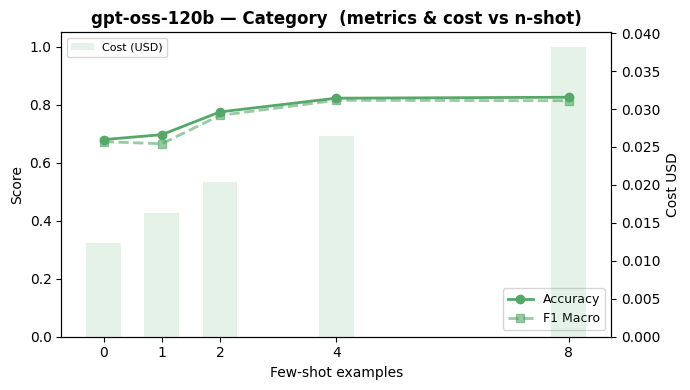

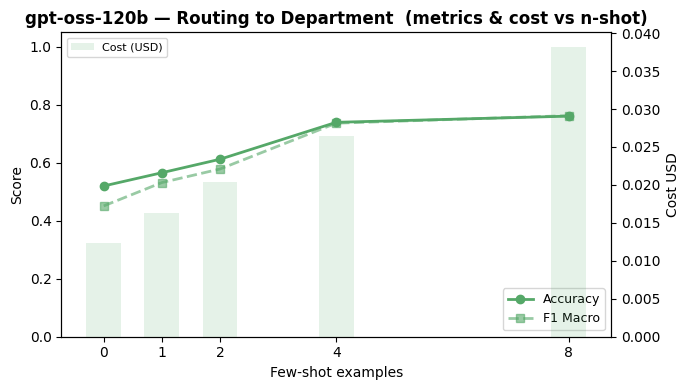

In [ ]:
for target in EVAL_COLUMNS:
    sub = df_phase2[df_phase2["target_column"] == target].sort_values("n_shot")

    fig, ax1 = plt.subplots(figsize=(7, 4))
    color_main = MODEL_PALETTE[best_model.model]

    ax1.plot(sub["n_shot"], sub["accuracy"], marker="o", lw=2, label="Accuracy", color=color_main)
    ax1.plot(
        sub["n_shot"],
        sub["f1_macro"],
        marker="s",
        lw=2,
        label="F1 Macro",
        color=color_main,
        alpha=0.6,
        linestyle="--",
    )
    ax1.set_xlabel("Few-shot examples")
    ax1.set_ylabel("Score")
    ax1.set_ylim(0, 1.05)
    ax1.set_xticks(FEW_SHOT_COUNTS)
    ax1.legend(loc="lower right", fontsize=9)

    ax2 = ax1.twinx()
    ax2.bar(
        sub["n_shot"], sub["cost_usd"], width=0.6, alpha=0.15, color=color_main, label="Cost (USD)"
    )
    ax2.set_ylabel("Cost USD")
    ax2.legend(loc="upper left", fontsize=8)

    ax1.set_title(
        f"{short_name(best_model.model)} — {target}  (metrics & cost vs n-shot)",
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

## Phase 2 — Heatmap (best n-shot per target)

In [ ]:
# Manual n-shot for comparison (must exist in phase2_predictions after Phase 2).
optimal_n_shot = 4  # change: 0, 1, 2, 4, 8, ...

_available = sorted(phase2_predictions.keys())
if optimal_n_shot not in phase2_predictions:
    raise ValueError(
        f"optimal_n_shot={optimal_n_shot} not in phase2_predictions {_available}. "
        "Run Phase 2 first or pick a value from FEW_SHOT_COUNTS."
    )

summary_opt = df_phase2[df_phase2["n_shot"] == optimal_n_shot][
    ["target_column", "accuracy", "f1_macro", "cost_usd"]
]
print(f"Metrics at optimal_n_shot={optimal_n_shot} (manual):")
display(summary_opt)

Metrics at optimal_n_shot=4 (manual):


target_column,accuracy,f1_macro,cost_usd
str,f64,f64,f64
"""Category""",0.8229,0.8154,0.026508
"""Routing to Department""",0.7396,0.7366,0.026508


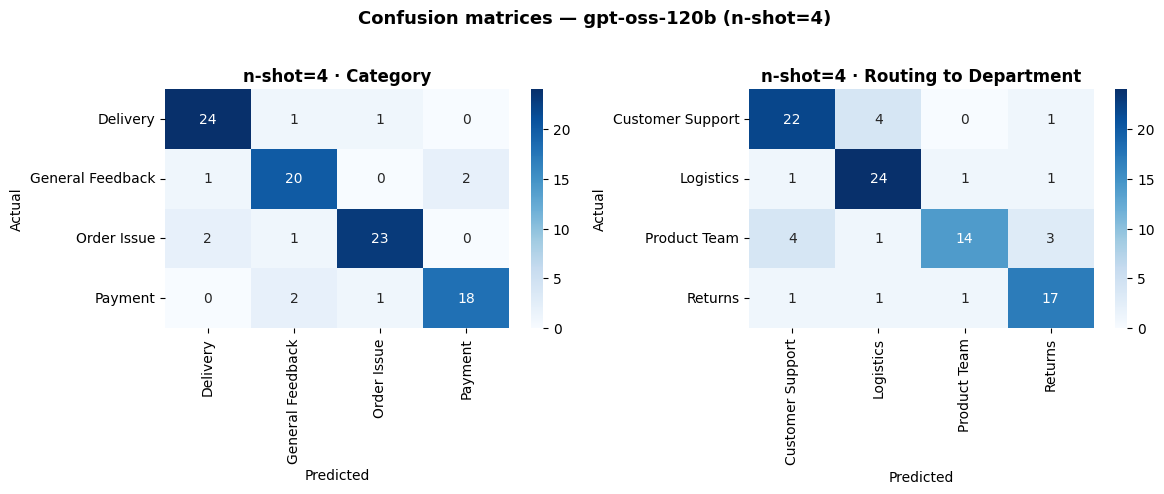

In [ ]:
from sklearn.metrics import confusion_matrix

_bm = getattr(best_model, "model", best_model)

n_shot = optimal_n_shot
pred_n = phase2_predictions[n_shot]
eval_n = phase2_eval_dfs[n_shot]
joined_n = pd.merge(eval_n, pred_n, on="row_id", how="inner", suffixes=("", "_pred"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

for ax, (gt_col, pred_col) in zip(axes, EVAL_COLUMNS.items(), strict=False):
    y_true = joined_n[gt_col].tolist()
    y_pred = joined_n[pred_col].tolist()
    labels = sorted(set(y_true) | set(y_pred))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
    )
    ax.set_title(f"n-shot={n_shot} · {gt_col}", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

fig.suptitle(
    f"Confusion matrices — {short_name(_bm)} (n-shot={n_shot})",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

# Final Prediction on Unseen Data

In [ ]:
print(
    f"Running final predictions with {short_name(best_model.model)}, "
    f"few-shot={optimal_n_shot}, temperature={TEMPERATURE}\n"
)

Running final predictions with gpt-oss-120b, few-shot=8, temperature=0.1



In [ ]:
df_to_predict = phase2_eval_dfs[optimal_n_shot]
few_shot_final = df_ground_truth.head(optimal_n_shot) if optimal_n_shot > 0 else None
n_pred = len(df_to_predict)

progress_final = tqdm(total=n_pred, desc="Final prediction")
df_final_predictions, final_usage = await run_extraction_async(
    df=df_to_predict,
    few_shot_df=few_shot_final,
    max_concurrency=MAX_CONCURRENCY,
    model=best_model.model,
    system_prompt=DEFAULT_SYSTEM_PROMPT,
    temperature=TEMPERATURE,
    progress_bar=progress_final,
    client=client,
)
progress_final.close()

NameError: name 'df_to_predict' is not defined

In [ ]:
final_cost = compute_cost(final_usage, best_model.model)
df_final = pd.merge(
    df_to_predict,
    df_final_predictions,
    on="row_id",
    how="left",
    suffixes=("", "_pred"),
)

print(f"\n  {n_pred} tickets classified.")
print(
    f"   Tokens — prompt: {final_usage['prompt_tokens']:,}  "
    f"completion: {final_usage['completion_tokens']:,}  "
    f"cost: ${final_cost:.6f}"
)
display(df_final)

# Module 3.3 metrics snapshot (H2/H3/H4/H6/H7) on the best labeled evaluation slice
eval_best = phase2_eval_dfs[optimal_n_shot]
pred_best = phase2_predictions[optimal_n_shot]
phase2_usage_row = df_phase2[df_phase2["n_shot"] == optimal_n_shot].iloc[0]
usage_best_eval = {
    "prompt_tokens": int(phase2_usage_row["prompt_tokens"]),
    "completion_tokens": int(phase2_usage_row["completion_tokens"]),
}

latency_ms_for_h7 = []
if "Latency" in df_final.columns:
    latency_ms_for_h7 = [
        float(x) for x in pd.to_numeric(df_final["Latency"], errors="coerce").dropna().tolist()
    ]

hypothesis_metrics = compute_hypothesis_metrics(
    gt_df=eval_best,
    pred_df=pred_best,
    usage=usage_best_eval,
    model=best_model.model,
    latency_ms=latency_ms_for_h7,
)

df_hypotheses = pd.DataFrame(
    [
        {
            "Hypothesis": "H2 Routing",
            "Metric": "Accuracy",
            "Value": round(hypothesis_metrics["h2_routing_accuracy"], 4),
        },
        {
            "Hypothesis": "H3 Drafts",
            "Metric": "Edit Similarity",
            "Value": round(hypothesis_metrics["h3_draft_edit_similarity"], 4),
        },
        {
            "Hypothesis": "H4 Safety",
            "Metric": "Escalation Rate",
            "Value": round(hypothesis_metrics["h4_safety_escalation_rate"], 4),
        },
        {
            "Hypothesis": "H6 Economics",
            "Metric": "Cost per Row (USD)",
            "Value": round(hypothesis_metrics["h6_cost_per_row_usd"], 6),
        },
        {
            "Hypothesis": "H7 Latency",
            "Metric": "P90 Latency (ms)",
            "Value": round(hypothesis_metrics["h7_p90_latency_ms"], 2),
        },
    ]
)

print("\nModule 3.3 hypothesis metrics snapshot:")
display(df_hypotheses)


  30 tickets classified.
   Tokens — prompt: 43,166  completion: 3,047  cost: $0.014321


row_id,Request Text,Submission Channel,Related to order,Order ID,Category,Routing to Department,Recognized,Timestamp,Order History,[Agent] Initial Response,"Confidence Level (low, medium. high)",Risks (yes/no),Cost,Latency,category,[Agent] Routing to Department,[Agent] Initial Response_pred
u32,str,str,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,str
0,"""Where is my order? I placed it…","""External Marketplace""","""yes""",770487,null,null,null,"""2025-10-01 7:21:01""","""2025-09-24 — Order placed for …",null,null,null,null,null,"""Delivery""","""Logistics""","""Hi there — thanks for reaching…"
1,"""Do you have this sofa in blue …","""Mobile App""","""-""",216739,null,null,null,"""2025-09-03 3:32:01""",null,null,null,null,null,null,"""General Feedback""","""Customer Support""","""Hi there — thanks for reaching…"
2,"""The mobile app keeps crashing …","""Mobile App""","""-""",126225,null,null,null,"""2025-09-22 0:25:01""",null,null,null,null,null,null,"""General Feedback""","""Product Team""","""Hi there — thanks for reaching…"
3,"""I want to return the jacket I …","""Website""","""yes""",877572,null,null,null,"""2025-09-18 10:12:01""","""2025-09-12 — Order placed for …",null,null,null,null,null,"""Order Issue""","""Returns""","""Hi there — thanks for reaching…"
4,"""You guys were really helpful t…","""External Marketplace""","""-""",388389,null,null,null,"""2025-09-06 2:43:01""",null,null,null,null,null,null,"""General Feedback""","""Customer Support""","""Hi there — thanks for the posi…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
25,"""I received two of the same ite…","""External Marketplace""","""yes""",308496,null,null,null,"""2025-09-02 20:18:44""","""2025-08-22 — Order placed for …",null,null,null,null,null,"""Order Issue""","""Returns""","""Hi there — thanks for reaching…"
26,"""Please confirm when my refund …","""Website""","""yes""",850800,null,null,null,"""2025-09-29 13:48:40""","""2025-09-17 — Order placed for …",null,null,null,null,null,"""Payment""","""Customer Support""","""Hi there — thanks for reaching…"
27,"""I want to add gift wrapping an…","""Mobile App""","""yes""",781453,null,null,null,"""2025-09-13 12:40:09""","""2025-09-05 — Order placed (Acc…",null,null,null,null,null,"""Order Issue""","""Customer Support""","""Hi there — thanks for reaching…"


### Module 3.3 mapping
- **H2 (Routing):** accuracy on `Category` vs predicted `category`.
- **H3 (Drafts):** normalized edit similarity between `[Human] Initial Response` and `[Agent] Initial Response`.
- **H4 (Safety):** escalation rate on risky-keyword subset (`lawyer`, `fire hazard`, `Spanish`) using routing/flags proxy.
- **H6 (Economics):** cost per row from token usage.
- **H7 (Latency):** p90 from `Latency` column when available.
